In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import seaborn as sns
sns.set()

In [ ]:
!du -sh /root/.cache/*

In [ ]:
!rm -rf /root/.cache/matplotlib

In [ ]:
!du -sh /root/.cache

56M	/root/.cache


In [3]:
import kagglehub
path = kagglehub.dataset_download("nih-chest-xrays/sample")

100%|██████████| 4.20G/4.20G [03:15<00:00, 23.1MB/s]

Extracting files...


In [ ]:
print(os.listdir(path))

['sample_labels.csv', 'sample']


In [4]:
train_df = pd.read_csv(os.path.join(path, "sample_labels.csv"))
# Print first 5 rows
print(f'There are {train_df.shape[0]} rows and {train_df.shape[1]} columns in this data frame')
train_df.head()

There are 5606 rows and 11 columns in this data frame


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5606 entries, 0 to 5605
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5606 non-null   object 
 1   Finding Labels               5606 non-null   object 
 2   Follow-up #                  5606 non-null   int64  
 3   Patient ID                   5606 non-null   int64  
 4   Patient Age                  5606 non-null   object 
 5   Patient Gender               5606 non-null   object 
 6   View Position                5606 non-null   object 
 7   OriginalImageWidth           5606 non-null   int64  
 8   OriginalImageHeight          5606 non-null   int64  
 9   OriginalImagePixelSpacing_x  5606 non-null   float64
 10  OriginalImagePixelSpacing_y  5606 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 481.9+ KB


In [ ]:
print(f"The total patient ids are {train_df['Patient ID'].count()}, from those the unique ids are {train_df['Patient ID'].value_counts().shape[0]} ")

The total patient ids are 5606, from those the unique ids are 4230 


DATA LABELS

In [ ]:
columns = train_df.keys()
columns = list(columns)
print(columns)

['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']


In [ ]:
columns.remove('Image Index')
columns.remove('Patient ID')
# Get the total classes
print(f"There are {len(columns)} columns of labels for these conditions: {columns}")

There are 9 columns of labels for these conditions: ['Finding Labels', 'Follow-up #', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']


Display Random Images


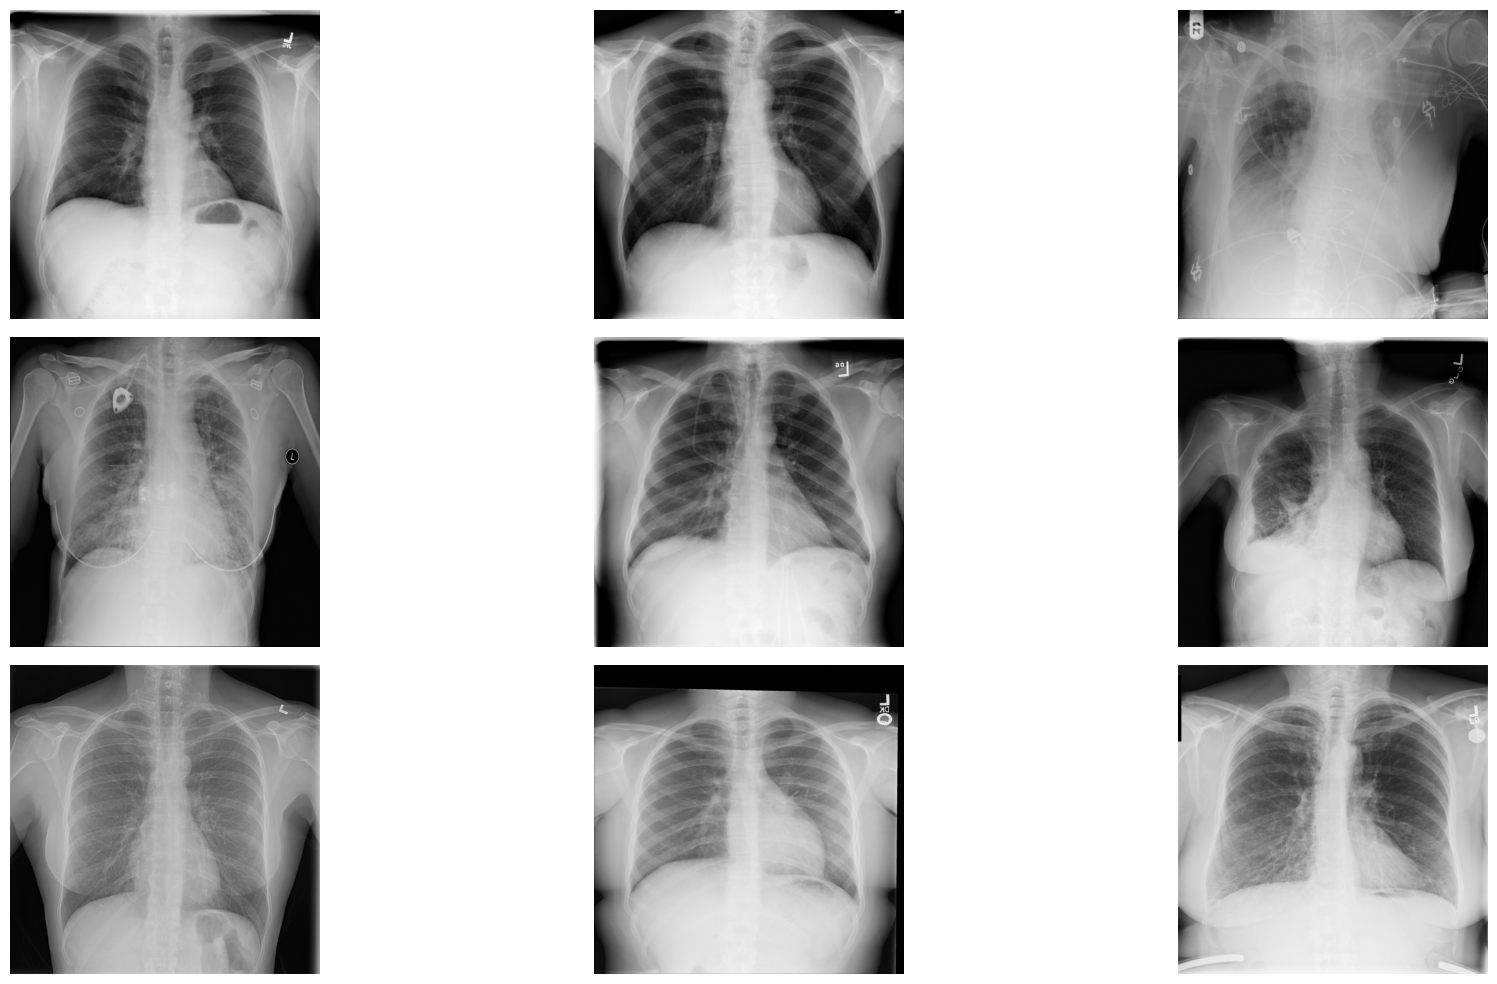

In [ ]:
# Extract numpy values from Image column in data frame
images = train_df['Image Index'].values

random_images = [np.random.choice(images) for i in range(9)]

# Location of the image dir
img_dir = os.path.join(path, 'sample', 'images')

print('Display Random Images')

# Adjust the size of your images
plt.figure(figsize=(20,10))

# Iterate and plot random images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(img_dir, random_images[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()

The dimensions of the image are 1024 pixels width and 1024 pixels height, one single color channel
The maximum pixel value is 1.0000 and the minimum is 0.0000
The mean value of the pixels is 0.3671 and the standard deviation is 0.1762


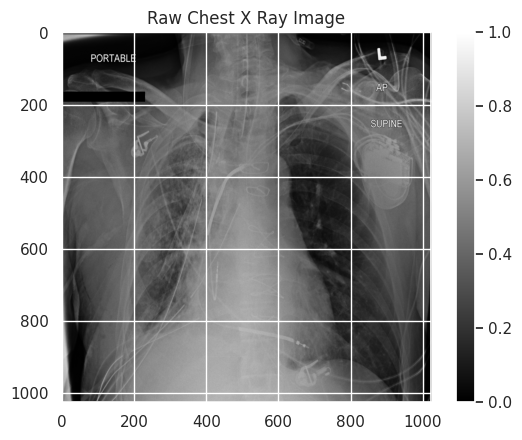

In [ ]:
# Get the first image that was listed in the train_df dataframe
sample_img = train_df['Image Index'][0]
raw_image = plt.imread(os.path.join(img_dir, sample_img))
plt.imshow(raw_image, cmap='gray')
plt.colorbar()
plt.title('Raw Chest X Ray Image')
print(f"The dimensions of the image are {raw_image.shape[0]} pixels width and {raw_image.shape[1]} pixels height, one single color channel")
print(f"The maximum pixel value is {raw_image.max():.4f} and the minimum is {raw_image.min():.4f}")
print(f"The mean value of the pixels is {raw_image.mean():.4f} and the standard deviation is {raw_image.std():.4f}")

/tmp/ipykernel_790/793168448.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(raw_image.ravel(),


Text(0, 0.5, '# Pixels in Image')

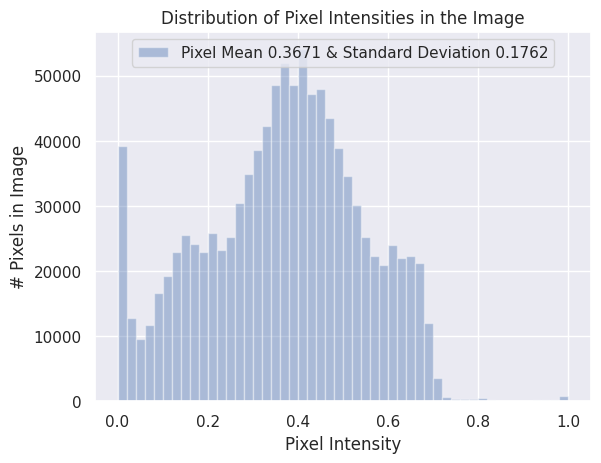

In [ ]:
# Plot a histogram of the distribution of the pixels
sns.distplot(raw_image.ravel(),
             label=f'Pixel Mean {np.mean(raw_image):.4f} & Standard Deviation {np.std(raw_image):.4f}', kde=False)
plt.legend(loc='upper center')
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixels in Image')

In [ ]:
# Import data generator from keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
image_generator = ImageDataGenerator(
    samplewise_center=True, #Set each sample mean to 0.
    samplewise_std_normalization= True # Divide each input by its standard deviation
)

In [ ]:
# Flow from directory with specified batch size and target image size

# Create 'Mass_Present' column for 'mass detection'
train_df['Mass_Present'] = train_df['Finding Labels'].apply(lambda x: 1 if 'Mass' in x else 0)

generator = image_generator.flow_from_dataframe(
        dataframe=train_df,
        directory=img_dir, # Use the correct image directory
        x_col="Image Index", # features - corrected column name
        # Let's say we build a model for mass detection
        y_col= ['Mass_Present'], # labels - corrected to a new binary column
        class_mode="raw", # 'Mass' column should be in train_df
        batch_size= 1, # images per batch
        shuffle=False, # shuffle the rows or not
        target_size=(320,320) # width and height of output image
)

Found 5606 validated image filenames.


The dimensions of the image are 320 pixels width and 320 pixels height
The maximum pixel value is 3.5952 and the minimum is -2.0900
The mean value of the pixels is -0.0000 and the standard deviation is 1.0000


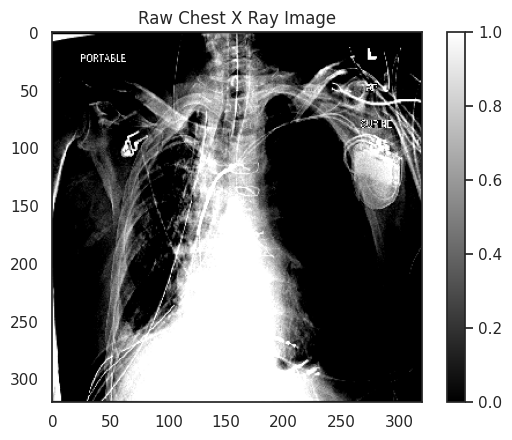

In [ ]:
# Plot a processed image
sns.set_style("white")
generated_image, label = generator.__getitem__(0)
plt.imshow(generated_image[0], cmap='gray')
plt.colorbar()
plt.title('Raw Chest X Ray Image')
print(f"The dimensions of the image are {generated_image.shape[1]} pixels width and {generated_image.shape[2]} pixels height")
print(f"The maximum pixel value is {generated_image.max():.4f} and the minimum is {generated_image.min():.4f}")
print(f"The mean value of the pixels is {generated_image.mean():.4f} and the standard deviation is {generated_image.std():.4f}")

/tmp/ipykernel_790/3108173275.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(raw_image.ravel(),
/tmp/ipykernel_790/3108173275.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(generated_image[0].ravel(),


Text(0, 0.5, '# Pixel')

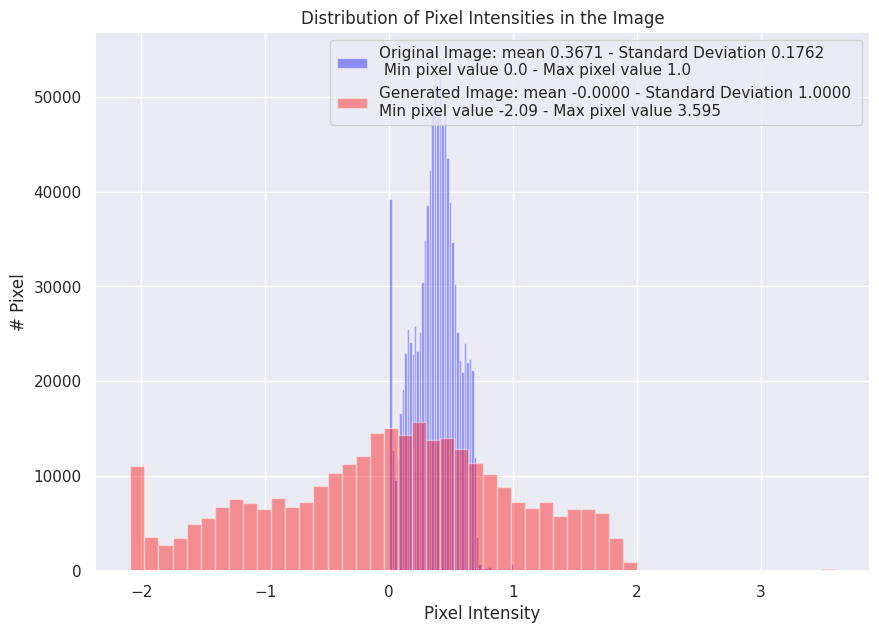

In [ ]:
# Include a histogram of the distribution of the pixels
sns.set()
plt.figure(figsize=(10, 7))

# Plot histogram for original iamge
sns.distplot(raw_image.ravel(),
             label=f'Original Image: mean {np.mean(raw_image):.4f} - Standard Deviation {np.std(raw_image):.4f} \n '
             f'Min pixel value {np.min(raw_image):.4} - Max pixel value {np.max(raw_image):.4}',
             color='blue',
             kde=False)

# Plot histogram for generated image
sns.distplot(generated_image[0].ravel(),
             label=f'Generated Image: mean {np.mean(generated_image[0]):.4f} - Standard Deviation {np.std(generated_image[0]):.4f} \n'
             f'Min pixel value {np.min(generated_image[0]):.4} - Max pixel value {np.max(generated_image[0]):.4}',
             color='red',
             kde=False)

# Place legends
plt.legend()
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixel')

Correcting class imbalance through weighted loss functions

In [5]:
# Count up the number of instances of each class (drop non-class columns from the counts)
class_counts = train_df.sum().drop(['Image Index','Patient ID'])


In [ ]:
for column in class_counts.keys():
    print(f"The class {column} has {train_df[column].sum()} samples")

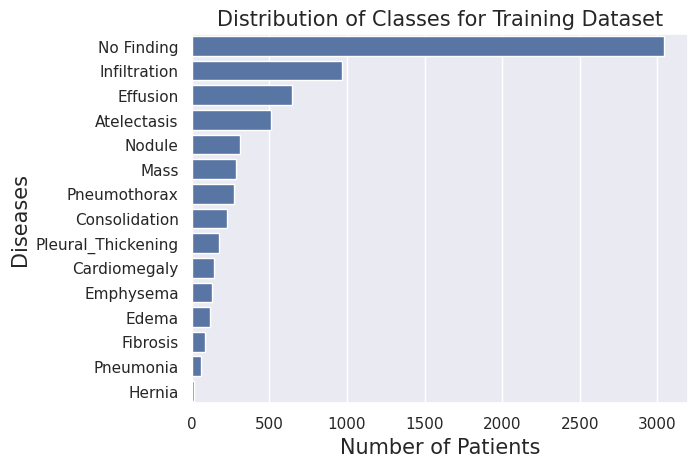

In [8]:

all_labels = train_df['Finding Labels'].str.split('|').explode()

# Get the counts for each unique label
class_counts_for_plot = all_labels.value_counts()

# Plot up the distribution of counts
sns.barplot(x=class_counts_for_plot.values, y=class_counts_for_plot.index, color='b')
plt.title('Distribution of Classes for Training Dataset', fontsize=15)
plt.xlabel('Number of Patients', fontsize=15)
plt.ylabel('Diseases', fontsize=15)
plt.show()

In [9]:
y_true = np.array(
        [[1],
         [1],
         [1],
         [0]])
print(f"y_true: \n{y_true}")

y_true: 
[[1]
 [1]
 [1]
 [0]]


In [10]:
# Make model predictions that are always 0.9 for all examples
y_pred_1 = 0.9 * np.ones(y_true.shape)
print(f"y_pred_1: \n{y_pred_1}")
print()
y_pred_2 = 0.1 * np.ones(y_true.shape)
print(f"y_pred_2: \n{y_pred_2}")

y_pred_1: 
[[0.9]
 [0.9]
 [0.9]
 [0.9]]

y_pred_2: 
[[0.1]
 [0.1]
 [0.1]
 [0.1]]


In [11]:
loss_reg_1 = -1 * np.sum(y_true * np.log(y_pred_1)) + \
                -1 * np.sum((1 - y_true) * np.log(1 - y_pred_1))
print(f"loss_reg_1: {loss_reg_1:.4f}")

loss_reg_1: 2.6187


In [12]:
loss_reg_2 = -1 * np.sum(y_true * np.log(y_pred_2)) + \
                -1 * np.sum((1 - y_true) * np.log(1 - y_pred_2))
print(f"loss_reg_2: {loss_reg_2:.4f}")

loss_reg_2: 7.0131


In [13]:
print(f"When the model 1 always predicts 0.9, the regular loss is {loss_reg_1:.4f}")
print(f"When the model 2 always predicts 0.1, the regular loss is {loss_reg_2:.4f}")

When the model 1 always predicts 0.9, the regular loss is 2.6187
When the model 2 always predicts 0.1, the regular loss is 7.0131


In [14]:
# calculate the positive weight as the fraction of negative labels
w_p = 1/4

# calculate the negative weight as the fraction of positive labels
w_n = 3/4

print(f"positive weight w_p: {w_p}")
print(f"negative weight w_n {w_n}")

positive weight w_p: 0.25
negative weight w_n 0.75


weighted loss of model 1

In [15]:
# Calculate and print out the first term in the loss function, which we are calling 'loss_pos'
loss_1_pos = -1 * np.sum(w_p * y_true * np.log(y_pred_1 ))
print(f"loss_1_pos: {loss_1_pos:.4f}")

loss_1_pos: 0.0790


In [16]:
# Calculate and print out the second term in the loss function, which we're calling 'loss_neg'
loss_1_neg = -1 * np.sum(w_n * (1 - y_true) * np.log(1 - y_pred_1 ))
print(f"loss_1_neg: {loss_1_neg:.4f}")

loss_1_neg: 1.7269


In [17]:
# Sum positive and negative losses to calculate total loss
loss_1 = loss_1_pos + loss_1_neg
print(f"loss_1: {loss_1:.4f}")

loss_1: 1.8060


weighted loss of model 2

In [18]:
# Calculate and print out the first term in the loss function, which we are calling 'loss_pos'
loss_2_pos = -1 * np.sum(w_p * y_true * np.log(y_pred_2))
print(f"loss_2_pos: {loss_2_pos:.4f}")

loss_2_pos: 1.7269


In [19]:
# Calculate and print out the second term in the loss function, which we're calling 'loss_neg'
loss_2_neg = -1 * np.sum(w_n * (1 - y_true) * np.log(1 - y_pred_2))
print(f"loss_2_neg: {loss_2_neg:.4f}")

loss_2_neg: 0.0790


In [20]:
# Sum positive and negative losses to calculate total loss when the prediction is y_pred_2
loss_2 = loss_2_pos + loss_2_neg
print(f"loss_2: {loss_2:.4f}")

loss_2: 1.8060


In [21]:
# See what happens when you set axis=0
print(f"using axis = 0 {np.sum(y_true,axis=0)}")

# Compare this to what happens when you set axis=1
print(f"using axis = 1 {np.sum(y_true,axis=1)}")

using axis = 0 [3]
using axis = 1 [1 1 1 0]


In [22]:
# set the positive weights as the fraction of negative labels (0) for each class (each column)
w_p = np.sum(y_true == 0,axis=0) / y_true.shape[0]
print(w_p)

[0.25]


In [23]:
# set the negative weights as the fraction of positive labels (1) for each class
w_n = np.sum(y_true == 1, axis=0) / y_true.shape[0]
print(w_n)

[0.75]


In [25]:
# Set model predictions where all predictions are the same
y_pred = np.ones(y_true.shape)
y_pred[:,0] = 0.3 * y_pred[:,0]
print(y_pred)

[[0.3]
 [0.3]
 [0.3]
 [0.3]]


In [26]:
# Print and view column zero of the weight
print(f"w_p[0]: {w_p[0]}")
print(f"y_true[:,0]: {y_true[:,0]}")
print(f"y_pred[:,0]: {y_pred[:,0]}")

w_p[0]: 0.25
y_true[:,0]: [1 1 1 0]
y_pred[:,0]: [0.3 0.3 0.3 0.3]


In [27]:
# calculate the loss from the positive predictions, for class 0
loss_0_pos = -1 * np.sum(w_p[0] *
                y_true[:, 0] *
                np.log(y_pred[:, 0])
              )
print(f"loss_0_pos: {loss_0_pos:.4f}")

loss_0_pos: 0.9030


In [28]:
# Print and view column zero of the weight
print(f"w_n[0]: {w_n[0]}")
print(f"y_true[:,0]: {y_true[:,0]}")
print(f"y_pred[:,0]: {y_pred[:,0]}")

w_n[0]: 0.75
y_true[:,0]: [1 1 1 0]
y_pred[:,0]: [0.3 0.3 0.3 0.3]


In [29]:
# Calculate the loss from the negative predictions, for class 0
loss_0_neg = -1 * np.sum(
                w_n[0] *
                (1 - y_true[:, 0]) *
                np.log(1 - y_pred[:, 0])
              )
print(f"loss_0_neg: {loss_0_neg:.4f}")

loss_0_neg: 0.2675


In [30]:
# add the two loss terms to get the total loss for class 0
loss_0 = loss_0_neg + loss_0_pos
print(f"loss_0: {loss_0:.4f}")

loss_0: 1.1705


In [34]:
loss_1_pos = -1 * np.sum(w_p[0] *
                y_true[:, 0] *
                np.log(y_pred[:, 0])
              )
print(f"loss_1_pos: {loss_1_pos:.4f}")

# Calculate the loss from the negative predictions, for class 1
loss_1_neg = -1 * np.sum(
                w_n[0] *
                (1 - y_true[:, 0]) *
                np.log(1 - y_pred[:, 0])
              )
print(f"loss_1_neg: {loss_1_neg:.4f}")

# add the two loss terms to get the total loss for class 1
loss_1 = loss_1_neg + loss_1_pos
print(f"loss_1: {loss_1:.4f}")

loss_1_pos: 0.9030
loss_1_neg: 0.2675
loss_1: 1.1705


/tmp/ipykernel_5137/2258891041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_for_plot.values, y=class_counts_for_plot.index, palette='viridis', ax=axes[0])
/tmp/ipykernel_5137/2258891041.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=balanced_data['Count'], y=balanced_data['Disease Label'], palette='viridis', ax=axes[1])


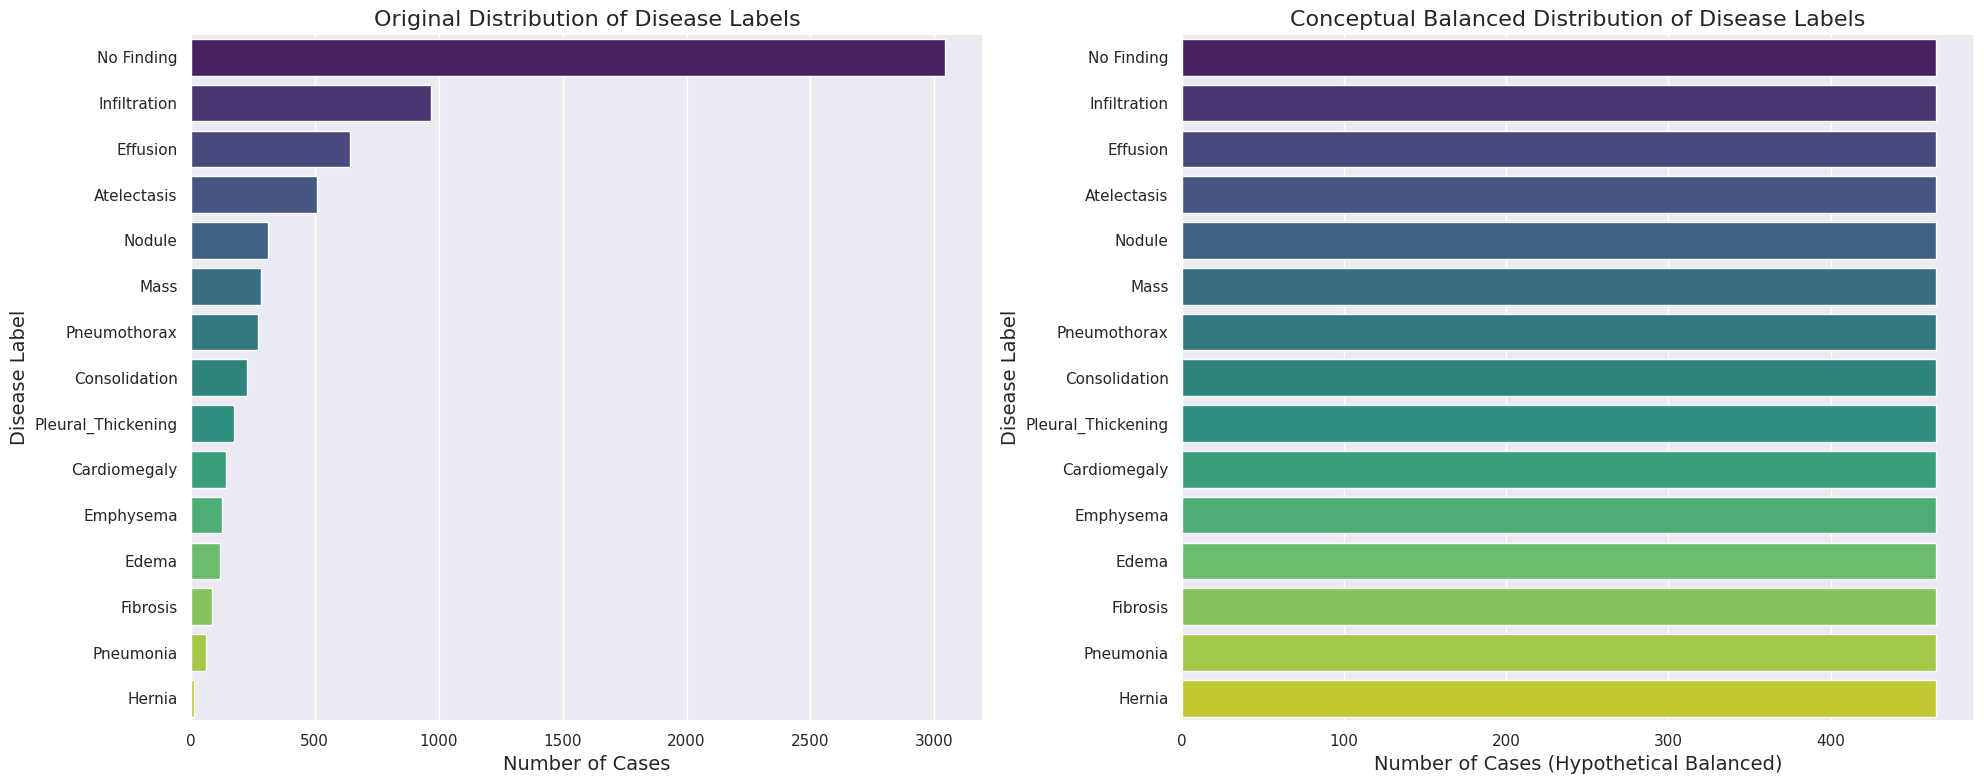

In [35]:
# Create a figure with two subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Original (Imbalanced) Distribution ---
sns.barplot(x=class_counts_for_plot.values, y=class_counts_for_plot.index, palette='viridis', ax=axes[0])
axes[0].set_title('Original Distribution of Disease Labels', fontsize=16)
axes[0].set_xlabel('Number of Cases', fontsize=14)
axes[0].set_ylabel('Disease Label', fontsize=14)


# Calculate a target count for conceptual balancing (e.g., the mean count)
target_count = class_counts_for_plot.mean()

# Create a DataFrame for the conceptual balanced data
balanced_data = pd.DataFrame({
    'Disease Label': class_counts_for_plot.index,
    'Count': [target_count] * len(class_counts_for_plot)
})

# Plot the conceptual balanced distribution
sns.barplot(x=balanced_data['Count'], y=balanced_data['Disease Label'], palette='viridis', ax=axes[1])
axes[1].set_title('Conceptual Balanced Distribution of Disease Labels', fontsize=16)
axes[1].set_xlabel('Number of Cases (Hypothetical Balanced)', fontsize=14)
axes[1].set_ylabel('Disease Label', fontsize=14)

plt.tight_layout()
plt.show()